In [1]:
import time
import tracemalloc
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx

from simpleai.search import (
    SearchProblem,
    breadth_first,
    depth_first,
    astar
)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [2]:
maze = np.array([
    [0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    [1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 0, 0, 1, 0]
])

start = (0, 0)
goal = (9, 9)

print("Tamaño del laberinto:", maze.shape)
print("Entrada:", start)
print("Salida:", goal)

Tamaño del laberinto: (10, 10)
Entrada: (0, 0)
Salida: (9, 9)


In [3]:
def draw_maze(maze, start, goal, path=None, title="Laberinto"):
    plt.figure(figsize=(7, 7))

    plt.imshow(maze, cmap="gray_r")

    # Entrada
    plt.scatter(
        start[1],
        start[0],
        marker="o",
        s=200,
        label="Entrada"
    )

    # Salida
    plt.scatter(
        goal[1],
        goal[0],
        marker="*",
        s=300,
        label="Salida"
    )

    # Camino encontrado
    if path is not None:
        y = [position[0] for position in path]
        x = [position[1] for position in path]

        plt.plot(
            x,
            y,
            linewidth=4,
            label="Solución"
        )

    plt.xticks(range(maze.shape[1]))
    plt.yticks(range(maze.shape[0]))
    plt.grid(True)

    plt.title(title)
    plt.legend()
    plt.show()

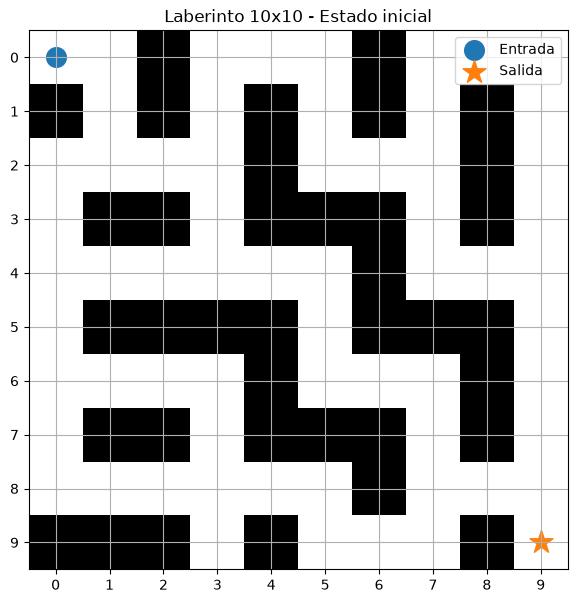

In [4]:
draw_maze(
    maze,
    start,
    goal,
    title="Laberinto 10x10 - Estado inicial"
)

In [5]:
class MazeProblem(SearchProblem):

    def __init__(self, maze, start, goal):
        self.maze = maze
        self.goal = goal

        super().__init__(initial_state=start)

    def actions(self, state):
        row, col = state

        movements = {
            "Arriba": (-1, 0),
            "Abajo": (1, 0),
            "Izquierda": (0, -1),
            "Derecha": (0, 1)
        }

        possible_actions = []

        for action, (dr, dc) in movements.items():

            new_row = row + dr
            new_col = col + dc

            if (
                0 <= new_row < self.maze.shape[0]
                and 0 <= new_col < self.maze.shape[1]
                and self.maze[new_row, new_col] == 0
            ):
                possible_actions.append(action)

        return possible_actions

    def result(self, state, action):
        row, col = state

        movements = {
            "Arriba": (-1, 0),
            "Abajo": (1, 0),
            "Izquierda": (0, -1),
            "Derecha": (0, 1)
        }

        dr, dc = movements[action]

        return row + dr, col + dc

    def is_goal(self, state):
        return state == self.goal

    def cost(self, state, action, state2):
        return 1

    def heuristic(self, state):
        return (
            abs(state[0] - self.goal[0])
            + abs(state[1] - self.goal[1])
        )

In [6]:
problem = MazeProblem(
    maze,
    start,
    goal
)

print("Problema del laberinto creado correctamente")

Problema del laberinto creado correctamente


In [7]:
solution_bfs = breadth_first(problem)

print("BFS encontró una solución.")
print("Número de movimientos:", len(solution_bfs.path()))

BFS encontró una solución.
Número de movimientos: 19


In [8]:
def solution_to_path(solution):
    
    path = []

    for action, state in solution:
        path.append(state)

    return path

In [9]:
path_bfs = solution_to_path(
    solution_bfs.path()
)

print("Coordenadas de la solución BFS:")
print(path_bfs)

Coordenadas de la solución BFS:
[(0, 0), (0, 1), (1, 1), (2, 1), (2, 2), (2, 3), (3, 3), (4, 3), (4, 4), (4, 5), (5, 5), (6, 5), (6, 6), (6, 7), (7, 7), (8, 7), (8, 8), (8, 9), (9, 9)]


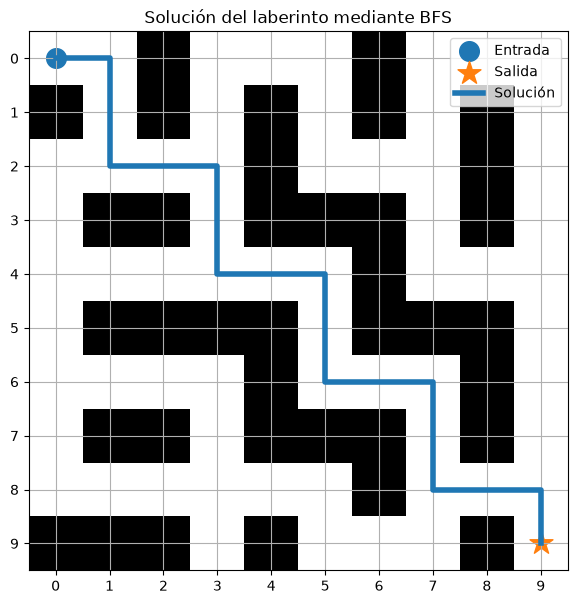

In [10]:
draw_maze(
    maze,
    start,
    goal,
    path_bfs,
    title="Solución del laberinto mediante BFS"
)

In [ ]:
solution_dfs = depth_first(problem)

print("DFS encontró una solución.")
print("Número de movimientos:", len(solution_dfs.path()))

In [ ]:
path_dfs = solution_to_path(
    solution_dfs.path()
)

print("Coordenadas de la solución DFS:")
print(path_dfs)

print("\nNúmero de posiciones:", len(path_dfs))
print("Inicio:", path_dfs[0])
print("Final:", path_dfs[-1])

In [ ]:
draw_maze(
    maze,
    start,
    goal,
    path_dfs,
    title="Solución del laberinto mediante DFS"
)